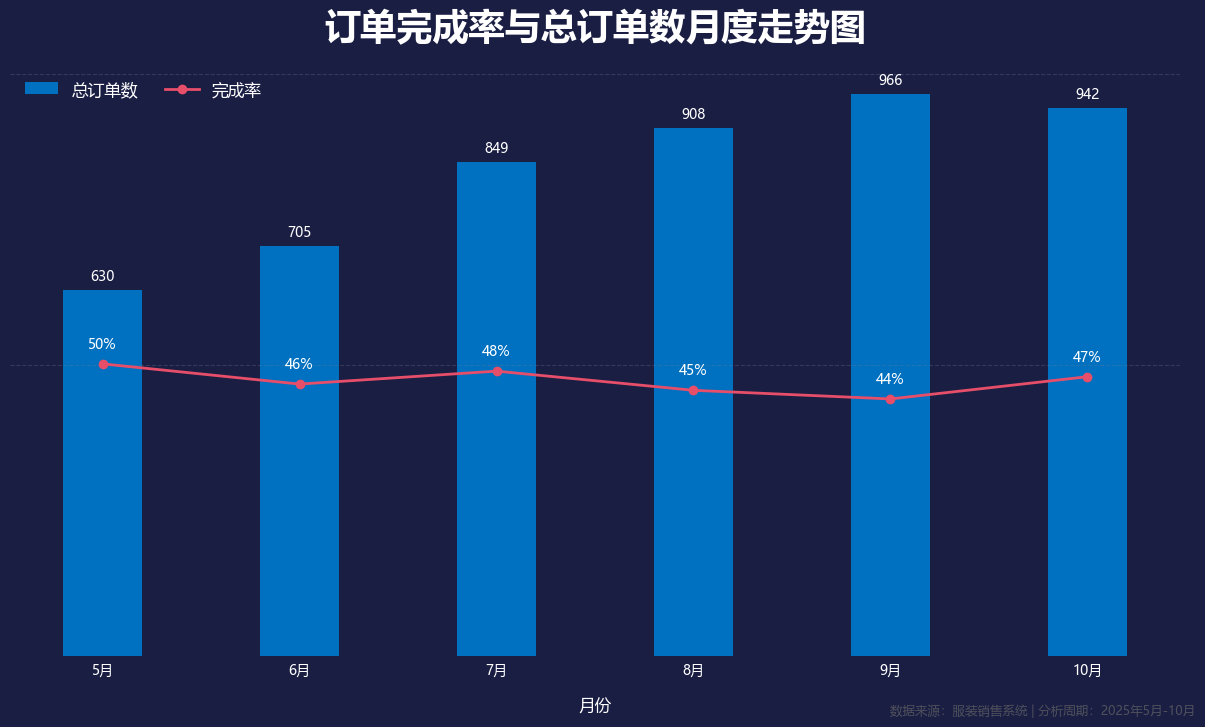

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取订单数据
    df = pd.read_csv("../../数据生成/erp_order.csv", encoding='utf-8-sig', parse_dates=["下单时间"])
    
    # 验证必要字段
    required_columns = ['下单时间', '状态']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺失必要字段: {', '.join(missing_cols)}")
    
    # 检查数据完整性
    if df.empty:
        raise ValueError("订单数据为空")
    if df['状态'].isnull().all():
        raise ValueError("订单状态数据全部为空")
    
    # 数据预处理
    df["月份"] = df["下单时间"].dt.to_period("M").astype(str)
    
    # 应用月份过滤，仅保留5月到10月的数据
    df = df[df["月份"].isin(['2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10'])]
    
    # 计算月度订单完成率
    month_summary = (
        df.groupby("月份")["状态"]
        .value_counts()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # 确保所有状态列存在
    status_columns = ["待付款", "已付款", "已发货", "已完成", "已取消"]
    for s in status_columns:
        if s not in month_summary.columns:
            month_summary[s] = 0
    
    # 计算总订单数和完成率
    month_summary["总订单数"] = month_summary[status_columns].sum(axis=1)
    month_summary["完成率"] = month_summary["已完成"] / month_summary["总订单数"]
    
    # 日期排序处理
    month_summary["月份_dt"] = pd.to_datetime(month_summary["月份"])
    month_summary = month_summary.sort_values("月份_dt")
    
    # 创建图表
    fig, ax1 = plt.subplots(figsize=(12, 8), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深色背景
    ax1.set_facecolor('#1A1E43')
    
    # 绘制总订单数柱状图
    ax1.bar(
        month_summary["月份"],
        month_summary["总订单数"],
        color="#0070c0",
        width=0.4,
        label='总订单数'
    )
    
    # 创建第二个Y轴用于完成率
    ax2 = ax1.twinx()
    offset = 0  # 定义线图偏移量
    
    # 绘制完成率线图
    ax2.plot(
        month_summary["月份"],
        (month_summary["完成率"] * 100) + offset,
        color="#e74e69",
        marker="o",
        markersize=6,
        linewidth=2,
        linestyle='-',
        label='完成率'
    )
    
    # 添加数据标注
    for x, y in zip(month_summary["月份"], month_summary["完成率"] * 100):
        ax2.text(x, (y + offset + 2), f"{y:.0f}%", ha="center", va="bottom", fontsize=10, color='white')
    
    for x, y in zip(month_summary["月份"], month_summary["总订单数"]):
        ax1.text(x, y + 10, f"{int(y)}", ha="center", va="bottom", fontsize=10, color='white')
    
    # 添加标题和标签
    plt.title("订单完成率与总订单数月度走势图", fontsize=26, fontweight="bold", color="#ffffff", pad=20)
    ax1.set_xlabel("月份", fontsize=12, color="#ffffff", labelpad=15)
    plt.figtext(
        1, 0.05,
        '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
        ha='right', fontsize=9, color='#666666', alpha=0.7
    )
    
    # 配置Y轴
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_ylim(0, 100)
    ax2.yaxis.set_major_locator(mtick.MultipleLocator(20))
    ax1.yaxis.set_major_locator(mtick.MultipleLocator(500))
    
    # 隐藏坐标轴边框
    for spine in ax1.spines.values():
        spine.set_visible(False)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    
    # 隐藏 y 轴刻度线
    ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    ax2.tick_params(axis='y', which='both', left=False, right=False, labelright=False)
    
    # 添加网格线
    ax1.grid(axis='y', linestyle="--", alpha=0.3, color='#777b92')
    ax1.grid(axis='x', visible=False)
    
    # 设置X轴标签
    ticks = list(range(len(month_summary["月份"])))
    labels = [f"{int(m.split('-')[1])}月" for m in month_summary["月份"]]
    ax1.set_xticks(ticks)
    ax1.set_xticklabels(labels)
    
    # 隐藏 x 轴刻度线
    ax1.tick_params(axis='x', which='both', length=0)
    ax1.xaxis.set_tick_params(colors='#ffffff')
    ax2.yaxis.set_tick_params(colors='#ffffff')
    
    # 添加图例
    ax1.legend(loc="upper left", bbox_to_anchor=(0, 1), fontsize=12, frameon=False, labelcolor="#ffffff", facecolor=fig.get_facecolor())
    ax2.legend(loc="upper left", bbox_to_anchor=(0.12, 0.998), fontsize=12, frameon=False, labelcolor="#ffffff", facecolor=fig.get_facecolor())
    
    # 调整布局
    plt.tight_layout(rect=(0, 0.03, 1, 0.95))
    
    # 保存图表
    plt.savefig(
        "总订单数与完成率月度走势图.png",
        dpi=300,
        bbox_inches='tight',
        facecolor=fig.get_facecolor(),
        transparent=True
    )
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **总订单数**：
  - 5月：630个订单
  - 6月：705个订单，环比增长12.2%
  - 7月：849个订单，环比增长20.4%
  - 8月：908个订单，环比增长7.0%
  - 9月：966个订单，环比增长6.4%
  - 10月：942个订单，环比下降2.5%

- **订单完成率**：
  - 5月：50%
  - 6月：46%
  - 7月：48%
  - 8月：45%
  - 9月：44%
  - 10月：47%


# 结论

从月度走势分析来看，总订单数整体呈现上升趋势，尤其在9月达到峰值966个订单。然而，订单完成率整体呈现下降趋势，从5月的50%下降至10月的47%。这可能表明随着订单量的增加，订单处理效率或客户满意度有所下降。